In [7]:
import os
from google.colab import files

files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
!kaggle datasets download -d prashant268/chest-xray-covid19-pneumonia

Dataset URL: https://www.kaggle.com/datasets/prashant268/chest-xray-covid19-pneumonia
License(s): unknown
100% 2.06G/2.06G [00:23<00:00, 95.0MB/s]



In [8]:
!unzip chest-xray-covid19-pneumonia.zip -d /content/chest-xray-covid19-pneumonia

Streaming output truncated to the last 5000 lines.
  inflating: /content/chest-xray-covid19-pneumonia/Data/train/COVID19/COVID19(228).jpg  
  inflating: /content/chest-xray-covid19-pneumonia/Data/train/COVID19/COVID19(229).jpg  
  inflating: /content/chest-xray-covid19-pneumonia/Data/train/COVID19/COVID19(23).jpg  
  inflating: /content/chest-xray-covid19-pneumonia/Data/train/COVID19/COVID19(230).jpg  
  inflating: /content/chest-xray-covid19-pneumonia/Data/train/COVID19/COVID19(231).jpg  
  inflating: /content/chest-xray-covid19-pneumonia/Data/train/COVID19/COVID19(232).jpg  
  inflating: /content/chest-xray-covid19-pneumonia/Data/train/COVID19/COVID19(233).jpg  
  inflating: /content/chest-xray-covid19-pneumonia/Data/train/COVID19/COVID19(234).jpg  
  inflating: /content/chest-xray-covid19-pneumonia/Data/train/COVID19/COVID19(235).jpg  
  inflating: /content/chest-xray-covid19-pneumonia/Data/train/COVID19/COVID19(236).jpg  
  inflating: /content/chest-xray-covid19-pneumonia/Data/trai

In [9]:
for dirpath, dirnames, filenames in os.walk("chest-xray-covid19-pneumonia"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 1 directories and 0 images in 'chest-xray-covid19-pneumonia'.
There are 2 directories and 0 images in 'chest-xray-covid19-pneumonia/Data'.
There are 3 directories and 0 images in 'chest-xray-covid19-pneumonia/Data/test'.
There are 0 directories and 855 images in 'chest-xray-covid19-pneumonia/Data/test/PNEUMONIA'.
There are 0 directories and 317 images in 'chest-xray-covid19-pneumonia/Data/test/NORMAL'.
There are 0 directories and 116 images in 'chest-xray-covid19-pneumonia/Data/test/COVID19'.
There are 3 directories and 0 images in 'chest-xray-covid19-pneumonia/Data/train'.
There are 0 directories and 3418 images in 'chest-xray-covid19-pneumonia/Data/train/PNEUMONIA'.
There are 0 directories and 1266 images in 'chest-xray-covid19-pneumonia/Data/train/NORMAL'.
There are 0 directories and 460 images in 'chest-xray-covid19-pneumonia/Data/train/COVID19'.


In [10]:
import tensorflow as tf
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
print(tf.__version__)

random.seed(0)
np.random.seed(0)
tf.random.set_seed(0)

2.20.0


In [20]:
import keras
from keras.models import Sequential
from keras.utils import to_categorical
from keras.layers import Activation, Dense, Conv2D, MaxPooling2D, Dropout, Flatten, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import itertools

In [12]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    shear_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    'chest-xray-covid19-pneumonia/Data/train/',
    batch_size=32,
    target_size=(64, 64),
    class_mode='categorical',
    shuffle=True,
    seed=0
)

valid_data = val_datagen.flow_from_directory(
    'chest-xray-covid19-pneumonia/Data/test/',
    batch_size=32,
    target_size=(64, 64),
    class_mode='categorical',
    seed=0
)

Found 5144 images belonging to 3 classes.
Found 1288 images belonging to 3 classes.


In [13]:
# Convert to tf.data dataset
train_ds = tf.data.Dataset.from_generator(
    lambda: train_data,
    output_signature=(
        tf.TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, 3), dtype=tf.float32)
    )
)

# Moderate class weights
class_weight_dict = {0: 2.5, 1: 1.0, 2: 0.6}

def add_sample_weights(images, labels):
    class_weights_tensor = tf.constant([2.5, 1.0, 0.6], dtype=tf.float32)
    sample_weights = tf.reduce_sum(labels * class_weights_tensor, axis=1)
    return images, labels, sample_weights

train_ds = train_ds.map(add_sample_weights)

In [8]:
def createModel():
    model = Sequential()
    model.add(Conv2D(32, (3, 3), use_bias=False, padding='same', input_shape=(64,64,3)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Conv2D(32, (3, 3), use_bias=False))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.3))

    model.add(Conv2D(64, (3, 3), use_bias=False, padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Conv2D(64, (3, 3), use_bias=False))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.2))

    model.add(Flatten())
    model.add(Dense(256))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.3))
    model.add(Dense(3, activation='softmax'))

    return model

In [9]:
model_cnn = createModel()
model_cnn.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 62, 62, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 31, 31, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 31, 31, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 3,279,459 (12.51 MB)

 Trainable params: 3,278,563 (12.51 MB)

 Non-trainable params: 896 (3.50 KB)

In [11]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,       # halve the LR when triggered
    patience=3,
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model_cnn.fit(train_ds,
                        epochs=5,        # let early stopping decide
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data),
                        callbacks=[reduce_lr, early_stop])

Epoch 1/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 106s 584ms/step - accuracy: 0.7891 - loss: 0.4737 - val_accuracy: 0.1079 - val_loss: 3.0373 - learning_rate: 0.0010
Epoch 2/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 82s 512ms/step - accuracy: 0.8554 - loss: 0.3167 - val_accuracy: 0.5707 - val_loss: 1.8125 - learning_rate: 0.0010
Epoch 3/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 84s 525ms/step - accuracy: 0.8748 - loss: 0.2768 - val_accuracy: 0.8773 - val_loss: 0.3515 - learning_rate: 0.0010
Epoch 4/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 82s 512ms/step - accuracy: 0.8785 - loss: 0.2711 - val_accuracy: 0.8432 - val_loss: 0.3625 - learning_rate: 0.0010
Epoch 5/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 84s 523ms/step - accuracy: 0.8941 - loss: 0.2379 - val_accuracy: 0.6405 - val_loss: 0.9305 - learning_rate: 0.0010


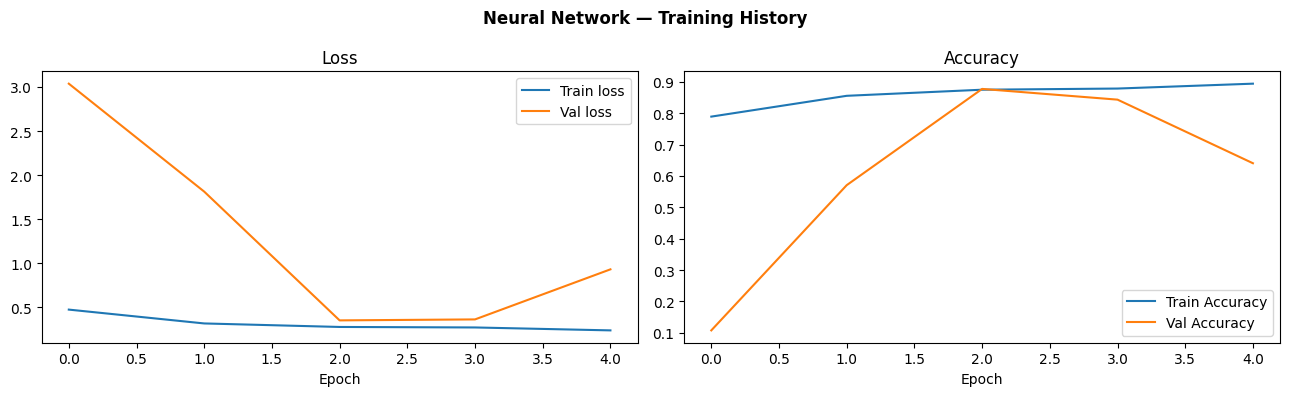

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'],     label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('Neural Network — Training History', fontweight='bold')
plt.tight_layout()
plt.show()

41/41 ━━━━━━━━━━━━━━━━━━━━ 15s 354ms/step


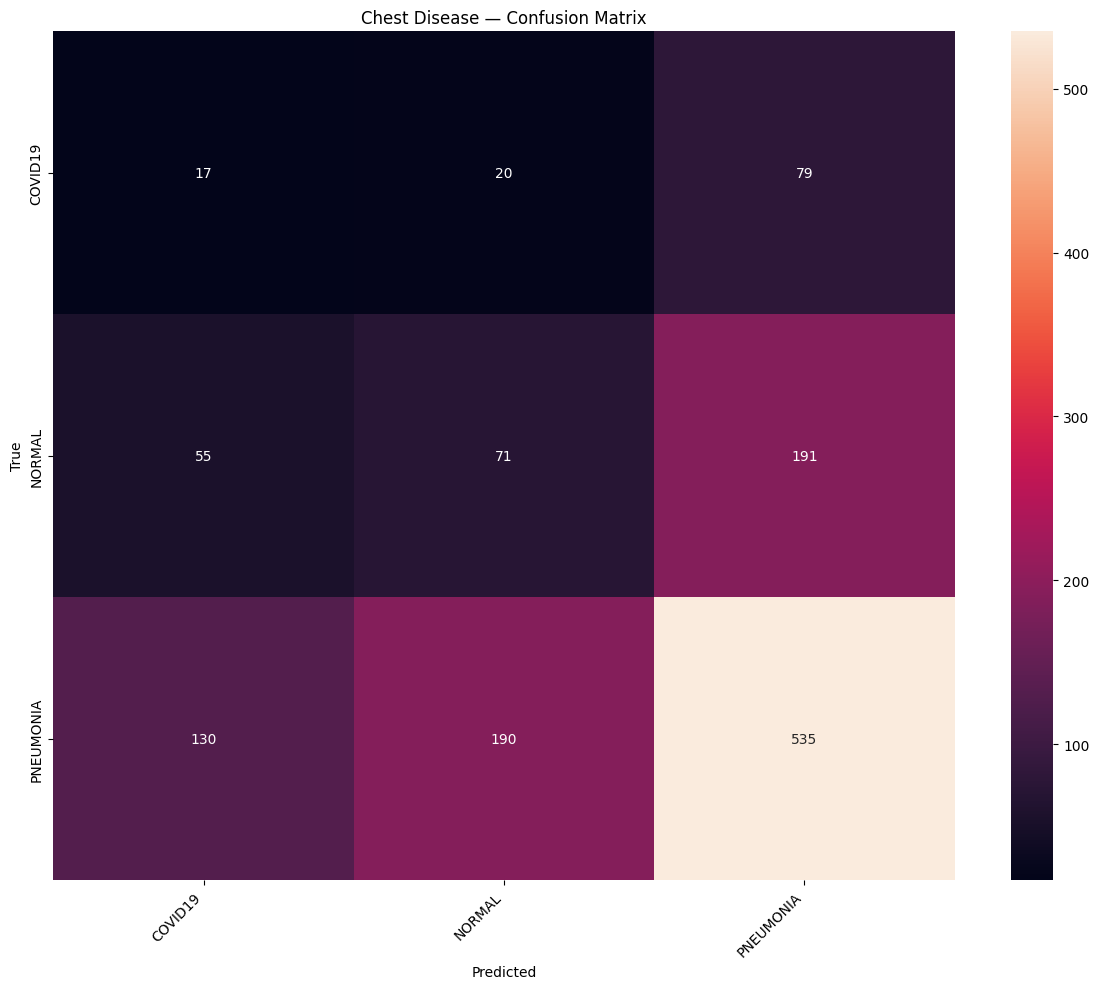

              precision    recall  f1-score   support

     COVID19       0.08      0.15      0.11       116
      NORMAL       0.25      0.22      0.24       317
   PNEUMONIA       0.66      0.63      0.64       855

    accuracy                           0.48      1288
   macro avg       0.33      0.33      0.33      1288
weighted avg       0.51      0.48      0.50      1288



In [13]:
from sklearn.metrics import confusion_matrix, classification_report

# Get true labels and predictions
y_true = valid_data.classes
y_pred = np.argmax(model_cnn.predict(valid_data), axis=1)

# Class names from the generator
class_names = list(valid_data.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='g',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Chest Disease — Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

On To CNNs with GPUs

In [14]:
train_datagen_cnn = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    shear_range=0.1
)

val_datagen_cnn = ImageDataGenerator(rescale=1./255)

train_data_cnn = train_datagen_cnn.flow_from_directory(
    'chest-xray-covid19-pneumonia/Data/train/',
    batch_size=32,
    target_size=(224, 224),
    class_mode='categorical',
    shuffle=True,
    seed=0
)

valid_data_cnn = val_datagen_cnn.flow_from_directory(
    'chest-xray-covid19-pneumonia/Data/test/',
    batch_size=32,
    target_size=(224, 224),
    class_mode='categorical',
    seed=0
)

Found 5144 images belonging to 3 classes.
Found 1288 images belonging to 3 classes.


In [16]:
import collections

from sklearn.utils.class_weight import compute_class_weight

y_train = train_data_cnn.classes
class_weights_cnn = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict_cnn = dict(enumerate(class_weights_cnn))
print(class_weight_dict_cnn)
print(collections.Counter(train_data_cnn.classes))
# maps 0→COVID, 1→NORMAL, 2→PNEUMONIA

{0: np.float64(3.727536231884058), 1: np.float64(1.3543970510795156), 2: np.float64(0.501657889604057)}
Counter({np.int32(2): 3418, np.int32(1): 1266, np.int32(0): 460})


In [17]:
# Convert to tf.data dataset
train_ds_cnn = tf.data.Dataset.from_generator(
    lambda: train_data_cnn,
    output_signature=(
        tf.TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, 3), dtype=tf.float32)
    )
)

# Moderate class weights
class_weight_dict = {0: 2.5, 1: 1.0, 2: 0.6}

def add_sample_weights(images, labels):
    class_weights_tensor = tf.constant([2.5, 1.0, 0.6], dtype=tf.float32)
    sample_weights = tf.reduce_sum(labels * class_weights_tensor, axis=1)
    return images, labels, sample_weights

train_ds_cnn = train_ds_cnn.map(add_sample_weights)

In [21]:
def createModel1():
    model1 = Sequential()

    model1.add(Conv2D(32, (3, 3), use_bias=False, padding='same', input_shape=(224,224,3)))
    model1.add(BatchNormalization())
    model1.add(Activation('relu'))
    model1.add(Conv2D(32, (3, 3), use_bias=False, padding='same'))
    model1.add(BatchNormalization())
    model1.add(Activation('relu'))
    model1.add(MaxPooling2D(pool_size=(2, 2)))
    model1.add(Dropout(0.25))

    model1.add(Conv2D(64, (3, 3), use_bias=False, padding='same'))
    model1.add(BatchNormalization())
    model1.add(Activation('relu'))
    model1.add(Conv2D(64, (3, 3), use_bias=False, padding='same'))
    model1.add(BatchNormalization())
    model1.add(Activation('relu'))
    model1.add(MaxPooling2D(pool_size=(2, 2)))
    model1.add(Dropout(0.25))

    model1.add(Conv2D(128, (3, 3), use_bias=False, padding='same'))
    model1.add(BatchNormalization())
    model1.add(Activation('relu'))
    model1.add(Conv2D(128, (3, 3), use_bias=False, padding='same'))
    model1.add(BatchNormalization())
    model1.add(Activation('relu'))
    model1.add(MaxPooling2D(pool_size=(2, 2)))
    model1.add(Dropout(0.25))

    model1.add(Conv2D(256, (3, 3), use_bias=False, padding='same'))
    model1.add(BatchNormalization())
    model1.add(Activation('relu'))
    model1.add(MaxPooling2D(pool_size=(2, 2)))
    model1.add(Dropout(0.25))

    model1.add(GlobalAveragePooling2D())
    model1.add(Dense(256))
    model1.add(BatchNormalization())
    model1.add(Activation('relu'))
    model1.add(Dropout(0.3))
    model1.add(Dense(3, activation='softmax'))

    return model1

In [22]:
model1 = createModel1()
model1.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 56, 56, 128)    │             

 Total params: 651,875 (2.49 MB)

 Trainable params: 649,955 (2.48 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [25]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,       # halve the LR when triggered
    patience=3,
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history1 = model1.fit(
    train_data_cnn,
    epochs=20,
    steps_per_epoch=len(train_data_cnn),
    validation_data=valid_data_cnn,
    validation_steps=len(valid_data_cnn),
    class_weight=class_weight_dict_cnn,
    callbacks=[reduce_lr, early_stop]
)

Epoch 1/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 143s 886ms/step - accuracy: 0.7939 - loss: 0.4604 - val_accuracy: 0.4876 - val_loss: 1.6605 - learning_rate: 0.0010
Epoch 2/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 138s 858ms/step - accuracy: 0.8256 - loss: 0.3852 - val_accuracy: 0.7112 - val_loss: 1.6748 - learning_rate: 0.0010
Epoch 3/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 145s 899ms/step - accuracy: 0.8357 - loss: 0.3450 - val_accuracy: 0.1172 - val_loss: 5.5566 - learning_rate: 0.0010
Epoch 4/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 195s 851ms/step - accuracy: 0.8493 - loss: 0.3277 - val_accuracy: 0.6273 - val_loss: 1.5198 - learning_rate: 0.0010
Epoch 5/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 135s 837ms/step - accuracy: 0.8600 - loss: 0.2916 - val_accuracy: 0.0901 - val_loss: 10.4908 - learning_rate: 0.0010
Epoch 6/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 134s 833ms/step - accuracy: 0.8781 - loss: 0.2609 - val_accuracy: 0.2927 - val_loss: 3.1524 - learning_rate: 0.0010
Epoch 7/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 135s 835ms/step - accur

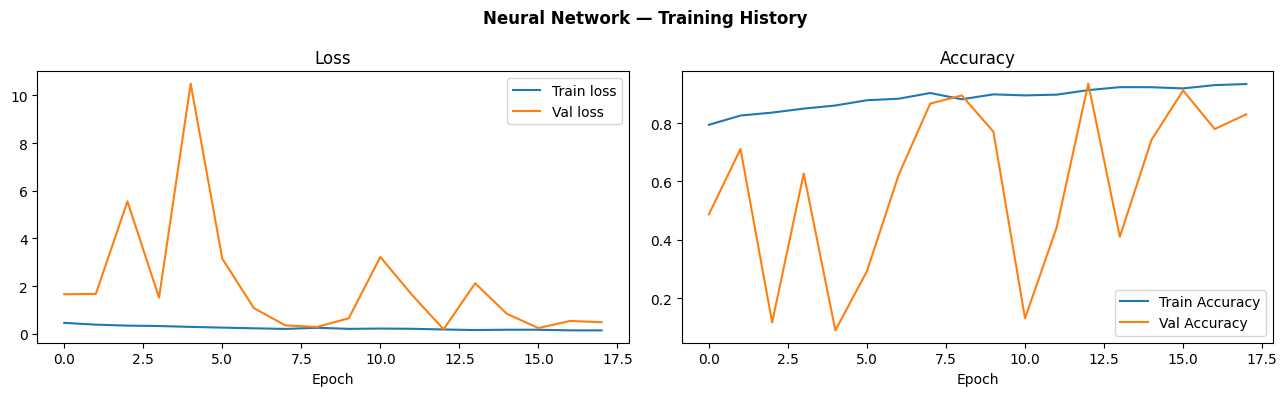

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history1.history['loss'],     label='Train loss')
axes[0].plot(history1.history['val_loss'], label='Val loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history1.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history1.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('Neural Network — Training History', fontweight='bold')
plt.tight_layout()
plt.show()

41/41 ━━━━━━━━━━━━━━━━━━━━ 15s 355ms/step


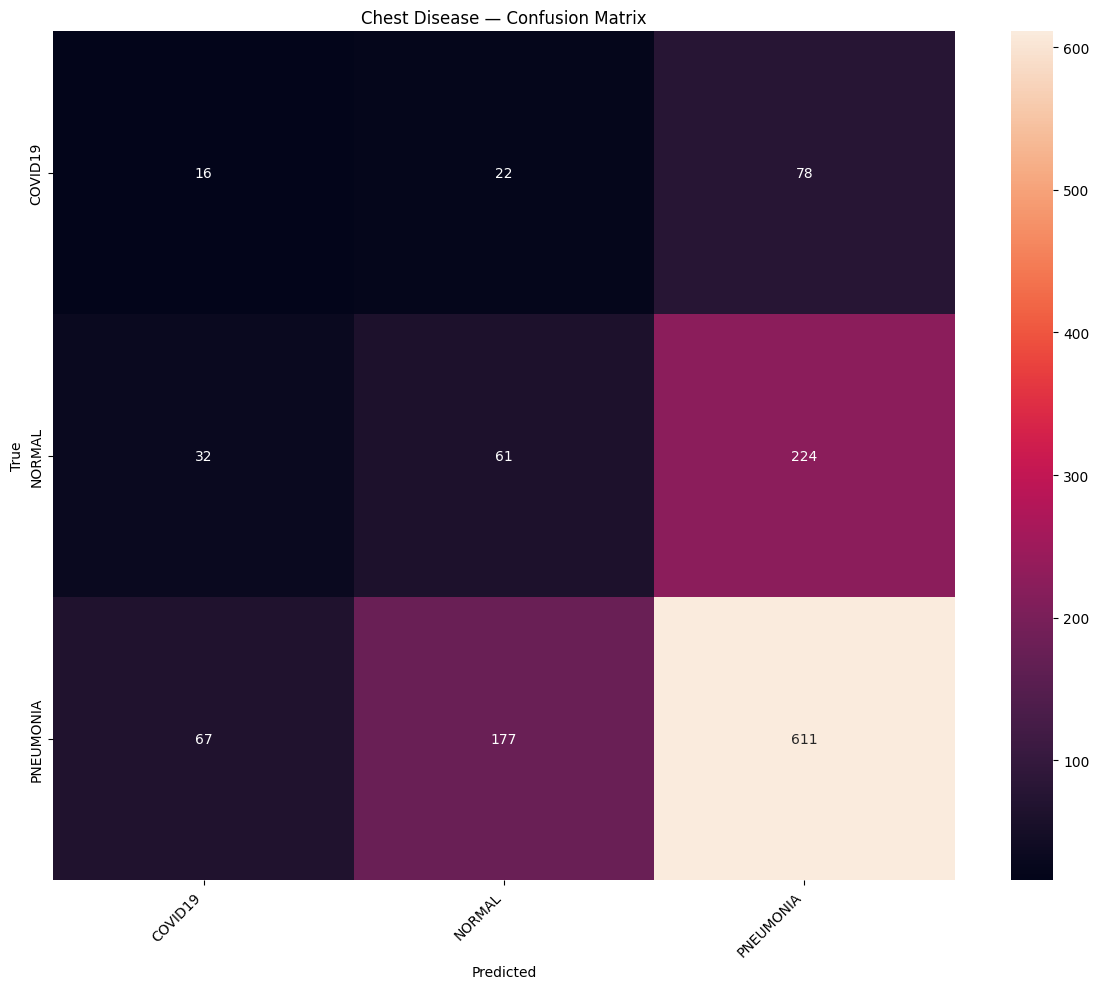

              precision    recall  f1-score   support

     COVID19       0.14      0.14      0.14       116
      NORMAL       0.23      0.19      0.21       317
   PNEUMONIA       0.67      0.71      0.69       855

    accuracy                           0.53      1288
   macro avg       0.35      0.35      0.35      1288
weighted avg       0.51      0.53      0.52      1288



In [28]:

# Get true labels and predictions
y_true = valid_data_cnn.classes
y_pred1 = np.argmax(model1.predict(valid_data_cnn), axis=1)

# Class names from the generator
class_names = list(valid_data_cnn.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred1)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='g',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Chest Disease — Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred1, target_names=class_names))